### 第5章 几何变换
#### 5.1 缩放
`dst = cv2.resize(src, dsize[, fx[, fy[, interpolation]])`
- 其中
    - dst 表示输出的目标图像，类型与src相同，其大小为dsize（非零值），或者通过src.size()、fx、fy计算得到
    - src 表示需要缩放的原始图像
    - dsize 代表输出图像大小
    - fx 代表水平方向的缩放比例
    - fy 代表垂直方向的缩放比例
    - interpolation 代表插值方式
- `fx = (double)dsize.width/src.cols; fy = (double)dsize.height/src.rows`
- `dsize = Size(round(fx*src.cols), round(fy*src.rows))`
- 当缩小图像时，区域插值方式(`cv2.INTER_AREA`)能够得到最好的效果；当放大图像时，使用三次样条插值(`cv2.INTER_CUBIC`)和双线性插值(`cv2.INTER_LINEAR`, 默认)都能够取得较好的效果。
- 在图像属性shape中，第一个值对应的是行数，第二个值对应的是列数；在dsize参数中，第一个值对应的是列数，第二个值对应的是行数
    

In [ ]:
import cv2
img = cv2.imread("test.bmp")
rows, cols=img.shape[:2]
size = (int(cols*0.9), int(rows*0.5))
rst1 = cv2.resize(img, size)
rst2 = cv2.resize(img, None, fx=2, fy=0.5)
print("img.shape=", img.shape)
print("rst1.shape=", rst1.shape)
print("rst2.shape=", rst2.shape)

img.shape= (512, 51, 3)
rst1.shape= (256, 45, 3)
rst2.shape= (256, 102, 3)


#### 5.2 翻转
`dst = cv2.flip(src, flipCode)`
- 其中
    - dst 代表和原始图像大小和类型相同的目标图像
    - src 表示要处理的原始图像
    - flipCode 表示旋转类型
        - 0：绕着x轴翻转
        - 任意正数：绕着y轴翻转
        - 任意负数：围绕x轴、y轴同时翻转

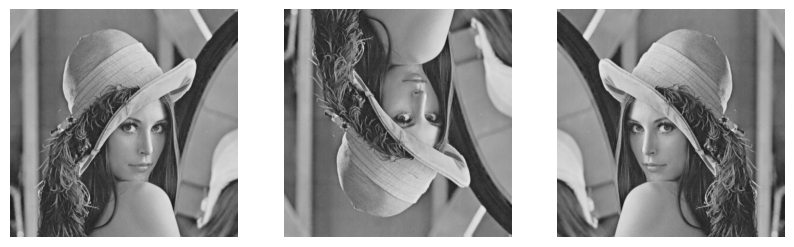

In [ ]:
# Jupyter Notebook 用 OpenCV 显示图像（内嵌不弹出独立窗口）
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
img = cv2.imread("lena.bmp")
x = cv2.flip(img, 0)
y = cv2.flip(img, 1)
xy = cv2.flip(img, -1)
# cv2.imshow("img", img)
# cv2.imshow("x", x)
# cv2.imshow("y", y)
# cv2.imshow("xy", xy)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.figure(figsize=(10, 5))  # 设置窗口大小, 若不设置则自动选取默认大小
plt.subplot(1,3,1)
plt.imshow(img)
plt.axis('off')  # 关闭坐标轴
plt.subplot(1,3,2)
plt.imshow(x)
plt.axis('off') 
plt.subplot(1,3,3)
plt.imshow(y)
plt.axis('off')
plt.show()

#### 5.3 仿射
`dst = cv2.warpAffine(src, M, dsize[, flags[, bordeMode[, borderValue]]])`
- 其中
    - dst 代表仿射后的输出图像，类型与src相同
    - src 表示要仿射的原始图像
    - M 表示一个$2 \times 3$的变换矩阵，不同的变换矩阵实现不同的仿射变换 
    $$ dst(x, y) = src(M_{11}x + M_{12}y + M_{13}, M_{21}x + M_{22}y + M_{23}) $$
    - dsize 代表输出图像的尺寸大小
    - flags 表示插值方法，默认值`INTER_LINEAR`; 若取值`WARP_INVERSE_MAP`表示M逆变换，实现从dst到src的逆变换
    - borderMode 代表边类型，默认为固定值填充`BORDER_CONSTANT`; `BORDER_TRANSPARENT`表示对于变换后映射到源图像外部的像素，不会修改 dst 中对应位置的像素值。
    - borderValue 代表边界值，默认为0

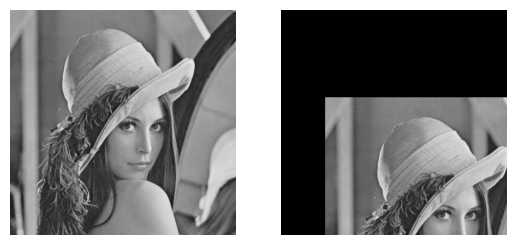

In [33]:
# 平移矩阵(向右移动100像素，向下移动200像素)
import cv2
import numpy as np
img = cv2.imread("lena.bmp")
height, width = img.shape[:2]
x = 100
y = 200
M = np.float32([[1, 0, x], [0, 1, y]])  
move = cv2.warpAffine(img, M, (width, height))
# cv2.imshow("original", img)
# cv2.imshow("move", move)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# plt.figure(figsize=(8, 4))  # 不设置figure，则默认宽 = 6.4 英寸，高 = 4.8 英寸
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(move)
plt.axis('off')
plt.show()

##### 5.3.1 旋转 
`retval = cv2.getRotationMatrix2D(center, angle, scale)`
- 其中：
    - retval 为返回的旋转矩阵
    - center 为旋转的中心点，通常以图像中心点`(width/2, height/2)`作为旋转中心点
    - angle 表示旋转角度，正数表示逆时针旋转，负数表示顺时针旋转
    - scale 为变换尺度（缩放大小）

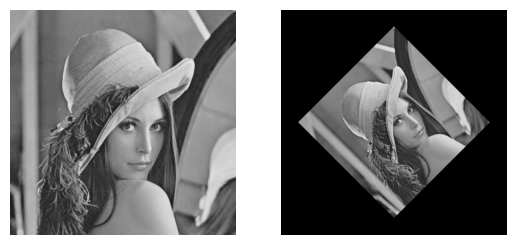

In [34]:
import cv2
img = cv2.imread("lena.bmp")
height, width = img.shape[:2]
M = cv2.getRotationMatrix2D((width/2, height/2), 45, 0.6)
rotate = cv2.warpAffine(img, M, (width,height))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(rotate)
plt.axis('off')
plt.show()

##### 5.3.2 更复杂的仿射变换 
`retval = cv2.getAffineTransform(src, dst)`
- 其中：
    - retval 为返回的旋转矩阵
    - src 和 dst 分别代表输入图像和输出图像的三个点，表示对应平行四边形的左上角、右上角和左下角

512 512


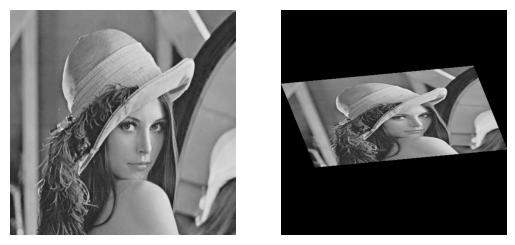

In [59]:
import cv2
import numpy as np
img = cv2.imread('lena.bmp')
rows, cols, ch = img.shape
print(rows, cols)
p1 = np.float32([[0, 0],[cols-1, 0],[0, rows-1]])
p2 = np.float32([[0, rows*0.33],[cols*0.85, rows*0.25],[cols*0.15, rows*0.7]])
M = cv2.getAffineTransform(p1, p2)
dst = cv2.warpAffine(img, M, (cols, rows))

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(dst)
plt.axis('off')
plt.show()

#### 5.4 透视
`dst = cv2.warpPerspective(src, M, dsize[, flags[, bordeMode[, borderValue]]])`
- 其中
    - dst 代表透视处理后的输出图像，类型与src相同
    - src 表示要透视的原始图像
    - M 表示一个$3 \times 3$的变换矩阵
    - dsize 代表输出图像的尺寸大小
    - flags 表示插值方法，默认值`INTER_LINEAR`; 若取值`WARP_INVERSE_MAP`表示M逆变换，实现从dst到src的逆变换
    - borderMode 代表边类型，默认为固定值填充`BORDER_CONSTANT`; `BORDER_TRANSPARENT`表示对于变换后映射到源图像外部的像素，不会修改 dst 中对应位置的像素值。
    - borderValue 代表边界值，默认为0

`retval = cv2.getPerspectiveTransform(src, dst)`用来生成对应的转换矩阵
- 其中：
    - retval 为返回的旋转矩阵
    - src 和 dst 分别代表输入图像和输出图像的四个顶点坐标

756 720


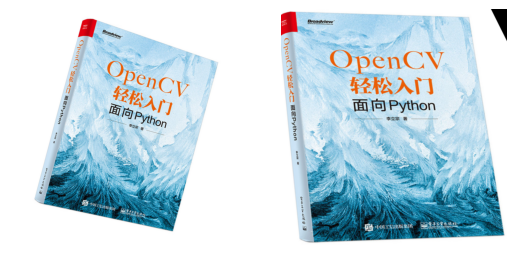

In [ ]:
import cv2
import numpy as np
img = cv2.imread('opencv.bmp')
rows, cols, ch = img.shape
print(rows, cols)
pts1 = np.float32([[230,60],[690,200],[80,580],[550,700]])
pts2 = np.float32([[50,50],[700,50],[50,700],[700,700]])    # 正视图
pts2 = np.float32([[0,50],[650,50],[50,700],[750,700]])     # 向左倾斜
M = cv2.getPerspectiveTransform(pts1, pts2)
dst = cv2.warpPerspective(img, M, (cols, rows))

# 注意：使用 matplotlib 必须 BGR 转 RGB，否则颜色失真
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(dst_rgb)
plt.axis('off')
plt.show()

#### 5.5 重映射

- 重映射：把一幅图像内的像素点放置到另一幅图像指定的对应位置
- `dst = cv2.remap(src, map1, map2, interpolation[, bordeMode[, borderValue]])`, 其中
    - dst 代表目标图像，类型和大小均与src相同
    - src 代表原始图像
    - 若map1 表示(x, y)点的映射时，map2的值为空；若map1表示CV_16SC2, CV_32FC1, CV_32FC2类型(x, y)点的x值，则map2表示对应点的y值
        - 因为map1决定列号(x轴方向)，map2决定行号(y轴方向)，通常分别写为`mapx`和`mapy`
    - interpolation 表示插值方式，这里不支持`INTER_AREA`
    - borderMode 代表边界模式，默认为固定值填充`BORDER_CONSTANT`; `BORDER_TRANSPARENT`表示对于变换后映射到源图像外部的像素，不会修改 dst 中对应位置的像素值。
    - borderValue 代表边界值，默认为0


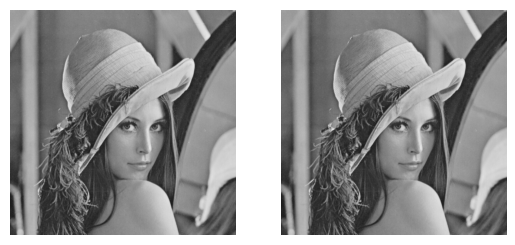

In [63]:
# 图像复制
import cv2
import numpy as np
img = cv2.imread("lena.bmp")
rows, cols = img.shape[:2]
mapx = np.zeros(img.shape[:2], np.float32)
mapy = np.zeros(img.shape[:2], np.float32)
for i in range(rows):
    for j in range(cols):
        mapx[i, j] = j    # NumPy 2.0 以后代替 itemset 
        mapy[i, j] = i
rst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(rst)
plt.axis('off')
plt.show()

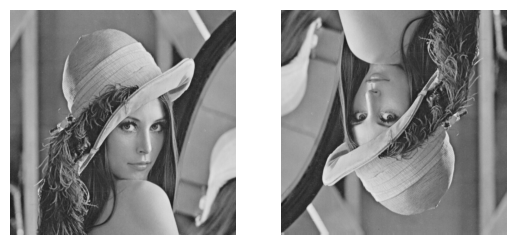

In [65]:
# 绕x轴、y轴翻转
import cv2
import numpy as np
img = cv2.imread("lena.bmp")
rows, cols = img.shape[:2]
mapx = np.zeros(img.shape[:2], np.float32)
mapy = np.zeros(img.shape[:2], np.float32)
for i in range(rows):
    for j in range(cols):
        mapx[i, j] = cols - 1 - j   # 水平翻转   
        mapy[i, j] = rows - 1 - i   # 垂直翻转
rst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(rst)
plt.axis('off')
plt.show()

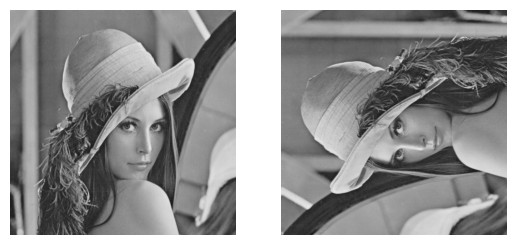

In [ ]:
# x轴和y轴互换，若行列数不一致，则无法映射的值全部为0
import cv2
import numpy as np
img = cv2.imread("lena.bmp")
rows, cols = img.shape[:2]
mapx = np.zeros(img.shape[:2], np.float32)
mapy = np.zeros(img.shape[:2], np.float32)
for i in range(rows):
    for j in range(cols):
        mapx[i, j] = i  
        mapy[i, j] = j   
rst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(rst)
plt.axis('off')
plt.show()

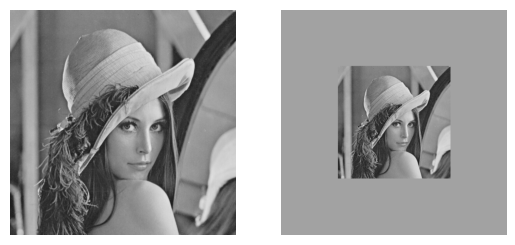

In [ ]:
# 图像缩放
import cv2
import numpy as np
img = cv2.imread("lena.bmp")
rows, cols=img.shape[:2]
mapx = np.zeros(img.shape[:2], np.float32)
mapy = np.zeros(img.shape[:2], np.float32)
for i in range(rows):
    for j in range(cols):
        if 0.25*rows< i <0.75*rows and 0.25*cols< j <0.75*cols:
                mapx[i, j] = 2*( j - cols*0.25 ) + 0.5  # 加0.5是校准像素中心，保证图像清晰、不偏移
                mapy[i, j] = 2*( i - rows*0.25 ) + 0.5
        else:     
                mapx[i, j] = 0
                mapy[i, j] = 0
rst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(rst)
plt.axis('off')
plt.show()

In [72]:
print(mapx.shape)

(512, 512)
